In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Processed Dataset(from Q1)

In [21]:
# Load the dataset
df = pd.read_csv('TaxiData.csv')

# Convert trip_start_timestamp to datetime
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'], unit='s')

# Ensure community areas are categorical
df['pickup_community_area'] = df['pickup_community_area'].astype('category')
df['dropoff_community_area'] = df['dropoff_community_area'].astype('category')

import warnings
warnings.filterwarnings("ignore")
# Impute numerical columns with mean
numerical_cols = ['fare', 'trip_miles', 'trip_seconds', 'tips']
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Impute categorical columns with mode or label as 'Unknown'
categorical_cols = ['payment_type', 'company','pickup_census_tract','dropoff_census_tract']
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

# Drop rows with missing latitude/longitude data if they are critical
df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'], inplace=True)

##  4.a Outliers in Fare and Tips

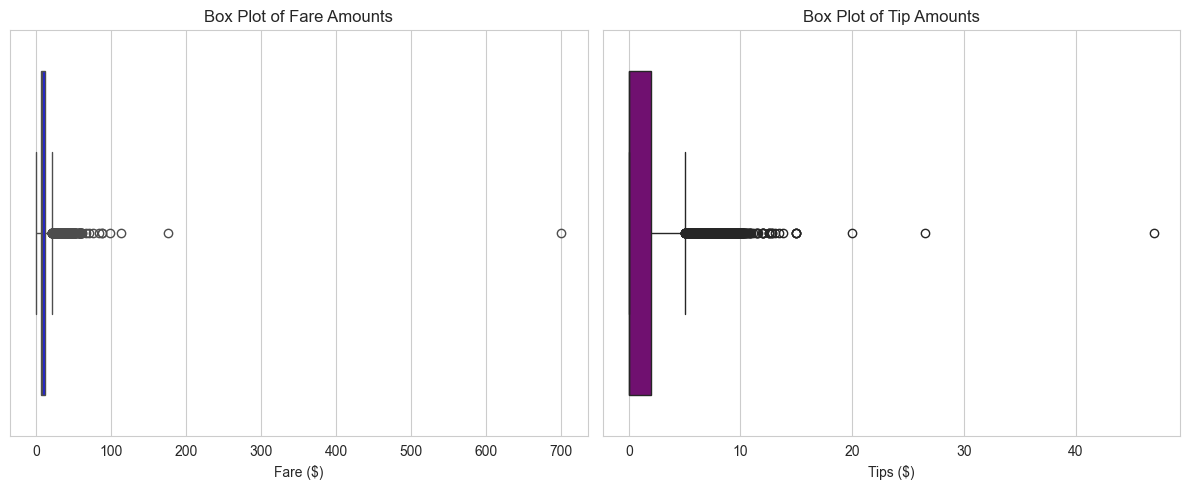

In [22]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

# Box plot for fare
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='fare', color='blue')
plt.title('Box Plot of Fare Amounts')
plt.xlabel('Fare ($)')

# Box plot for tips
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='tips', color='purple')
plt.title('Box Plot of Tip Amounts')
plt.xlabel('Tips ($)')

plt.tight_layout()
plt.show()


```
(b) Interpretation: These outliers might skew average calculations as follows:
Fare Outliers:
High outliers in fare values (e.g., very long or special trips) will significantly increase the mean (average) fare. This might make the average fare seem higher than what a typical trip would cost.
If the dataset includes a few extremely high fare values, the mean becomes less representative of the typical fare, as it will be pulled up by these outliers.
The median fare is generally less affected by outliers and might better represent the central tendency in this case.

Tip Outliers:
Similar to fares, a few very high tip values will skew the mean tip upwards. Given that most tips are close to zero or small, this effect makes the mean tip value an overestimate of the "typical" tipping behavior.
This skew might lead to misinterpretation if using the mean as a measure of central tendency for tipping behavior, as most customers tip minimally or not at all.
```

In [23]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Apply outlier removal to relevant numerical columns
df = remove_outliers(df, ['fare', 'trip_miles', 'trip_seconds'])

```
(c) Methods for handling these outliers in predictive models
1.) InterQuartile Range (IQR) method
The Interquartile Range (IQR) method is a popular statistical technique for detecting outliers in a dataset. It is based on the spread of the middle 50% of the data, which helps identify values that are unusually high or low compared to the bulk of the data.

2.)Capping (or Winsorizing):
Capping involves limiting extreme values to a maximum threshold, such as setting all fares above the 95th percentile to the 95th percentile value. This technique reduces the impact of outliers without completely discarding them.

```

## 4.b Predicting Fare

RMSE: 1.3171885556566028
MAE: 0.8156969231148341


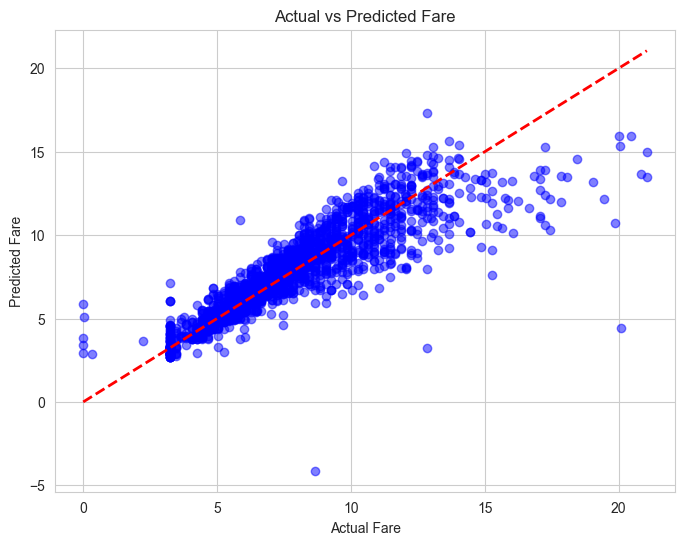

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df[['trip_miles', 'trip_seconds', 'pickup_community_area', 'dropoff_community_area']]
y = df['fare']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['pickup_community_area', 'dropoff_community_area'])
    ], remainder='passthrough'
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()


```
(c) while the linear regression model provides a basic estimation of fares based on distance, duration, and location, its effectiveness may be limited by its inability to capture nonlinear fare structures and its lack of crucial features. For improved accuracy, exploring more advanced models, adding relevant features, and addressing limitations with additional data would be beneficial.
```